<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-2/HW2_322512690_21239353_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2**  - Deep Learning Winter 2024

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



**First step we load the data from the torchvision libary and split the data into Test and training and validation**

In [27]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F  # Added F for functional API


# Step 1: Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize the dataset
])
# Load training and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Step 2: Split the training dataset into training and validation sets
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # Remaining 20% for validation

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


**Task1 : building the first CNN as ordered we made an img to describe and understand what really happen **

In [28]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 10)  # CIFAR-10 has 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc1(x)
        return x


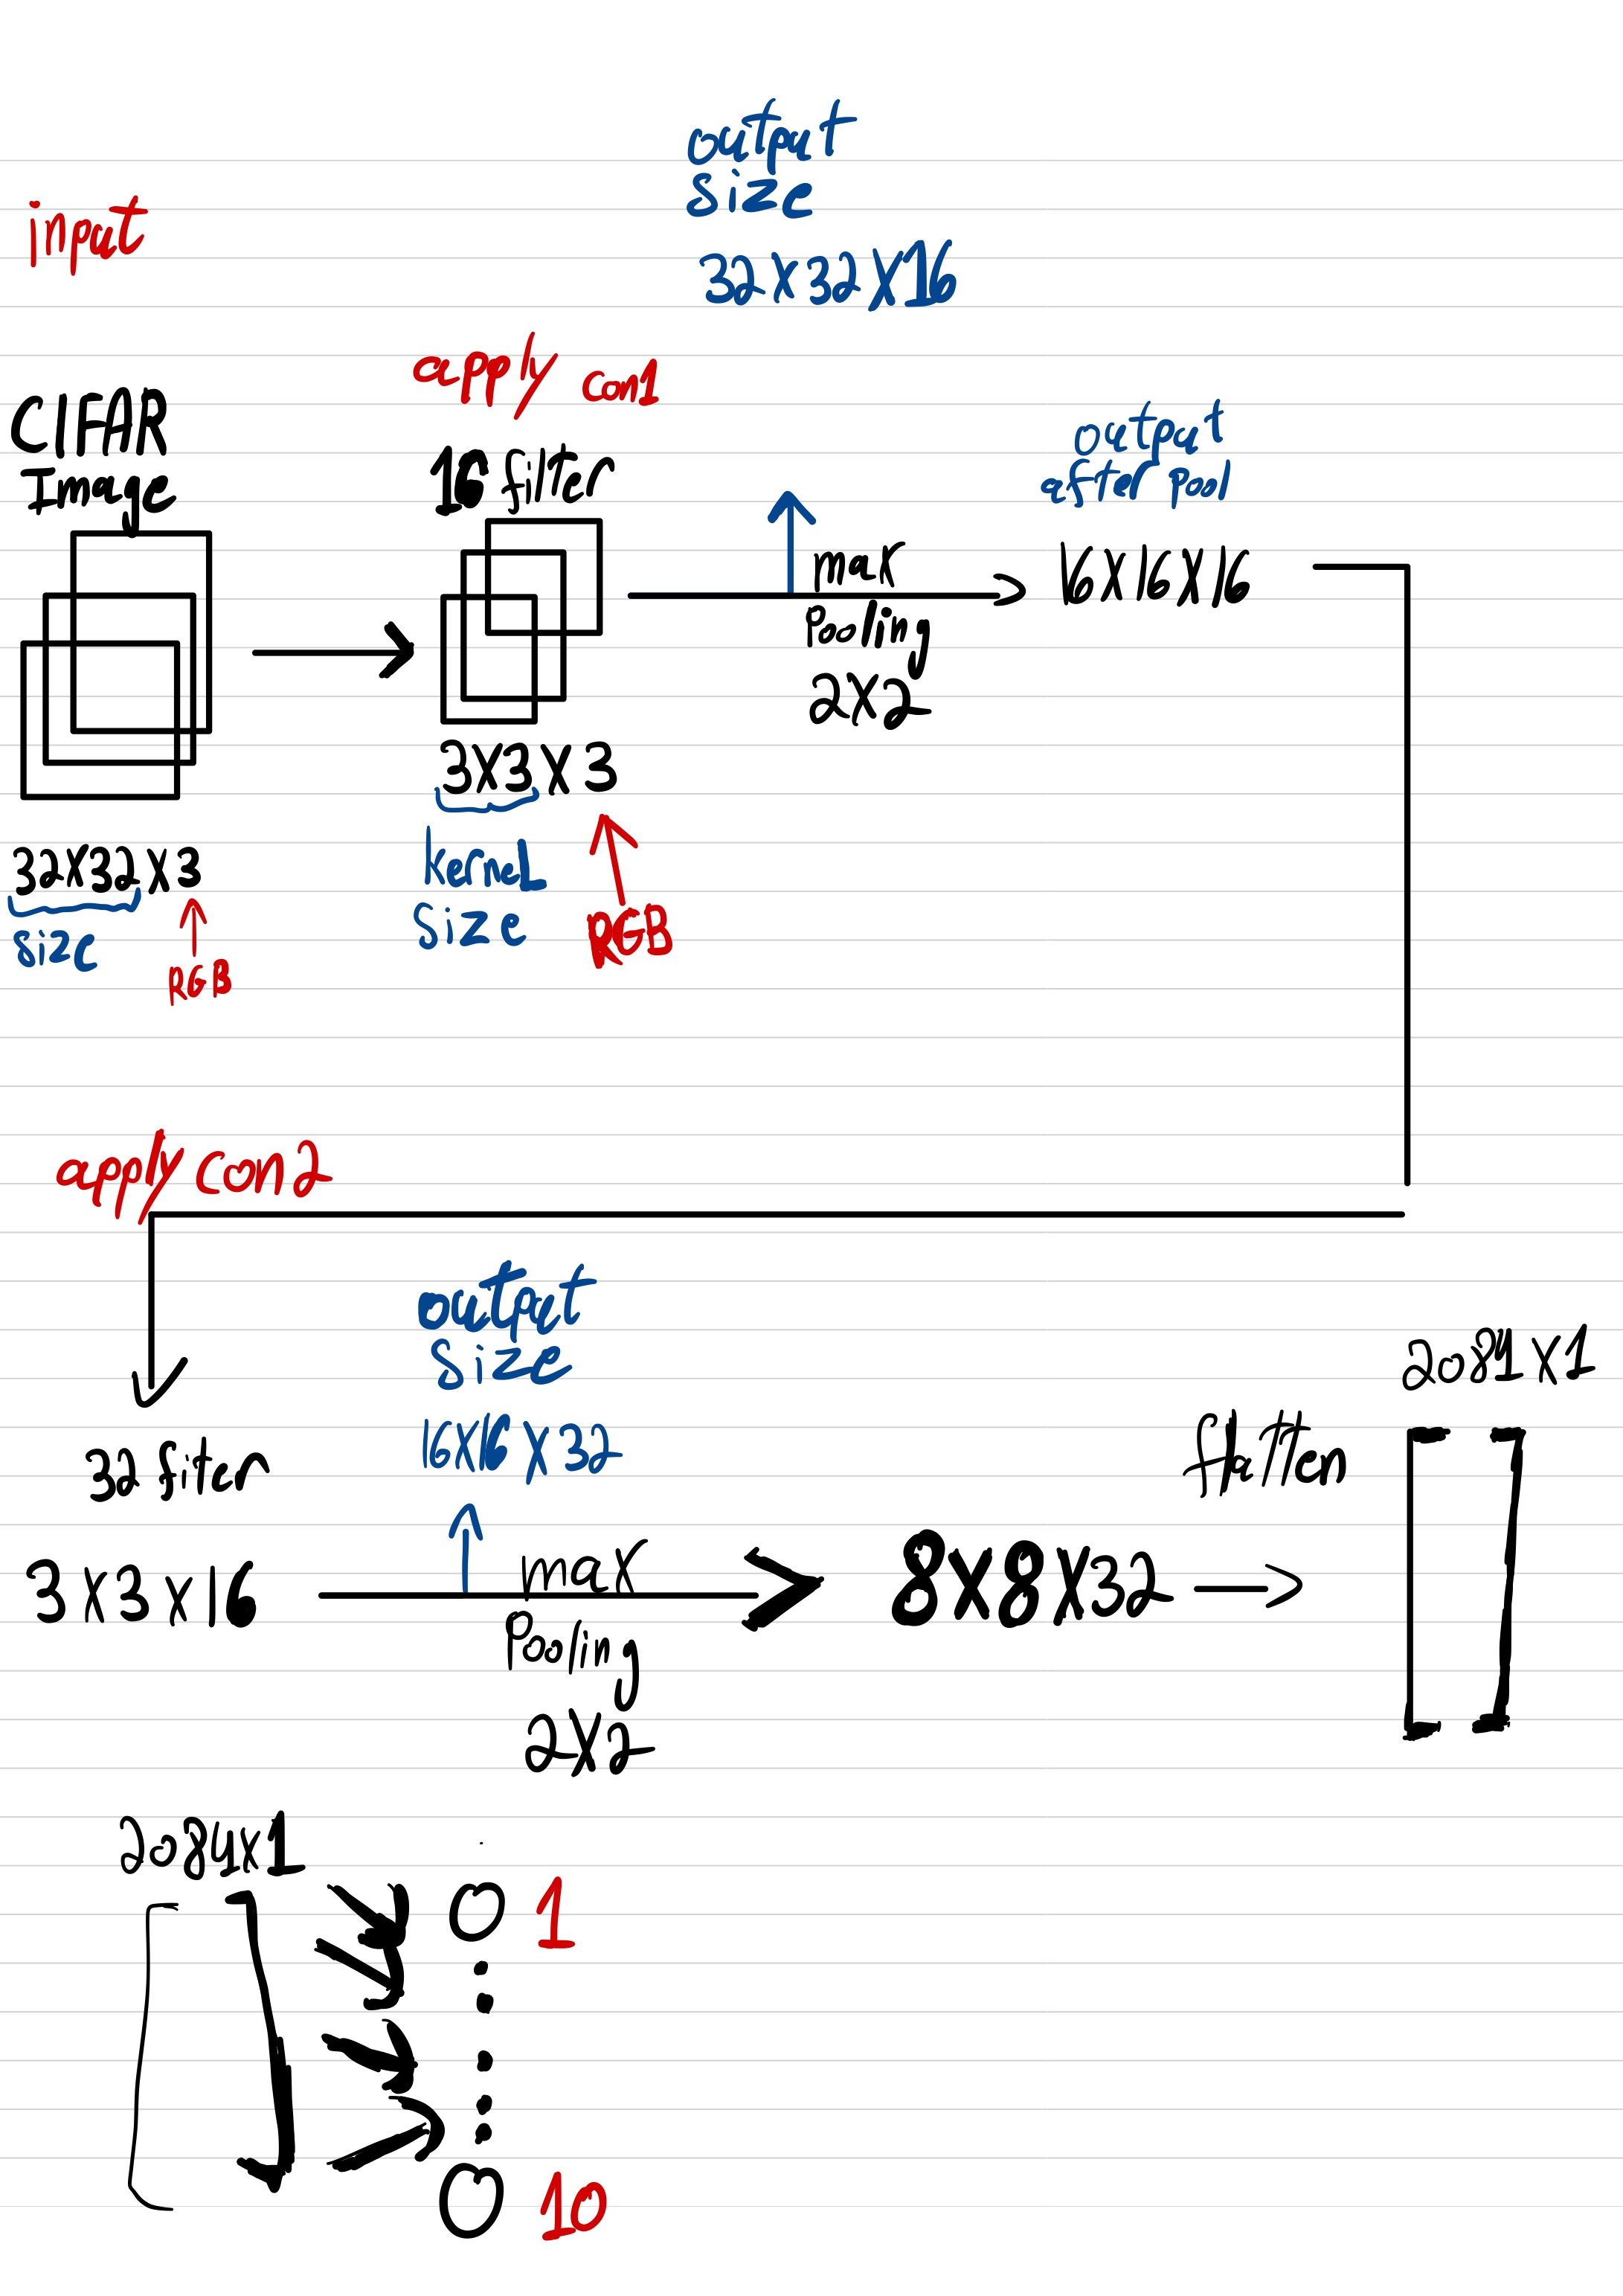

**Made an function for training the model with 10 epochcs which gets the appropirate net (according to task) **

In [29]:
def train_and_validate(net, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    best_val_accuracy = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training phase
        net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total

        # Validation phase
        net.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for data in val_loader:
                inputs, labels = data
                outputs = net(inputs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total

        # Save the best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = net.state_dict()

        print(f'Epoch {epoch + 1}/{num_epochs} Loss: {running_loss / len(train_loader):.3f} Train Accuracy: {train_accuracy:.2f}% Validation Accuracy: {val_accuracy:.2f}%')

    print('Finished Training')
    net.load_state_dict(best_model_state)
    return net


**For testing the Model**

In [30]:
def test_model(net, test_loader):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy of the best model on the 10000 test images: {100 * correct / total:.2f}%')


**Results for the first CNN task 1 :**

In [16]:
net = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)


Epoch 1/10 Loss: 1.503 Train Accuracy: 46.82% Validation Accuracy: 55.07%
Epoch 2/10 Loss: 1.191 Train Accuracy: 58.22% Validation Accuracy: 61.23%
Epoch 3/10 Loss: 1.067 Train Accuracy: 63.06% Validation Accuracy: 63.69%
Epoch 4/10 Loss: 0.987 Train Accuracy: 65.79% Validation Accuracy: 65.32%
Epoch 5/10 Loss: 0.936 Train Accuracy: 67.59% Validation Accuracy: 65.53%
Epoch 6/10 Loss: 0.890 Train Accuracy: 69.30% Validation Accuracy: 64.92%
Epoch 7/10 Loss: 0.856 Train Accuracy: 70.30% Validation Accuracy: 66.48%
Epoch 8/10 Loss: 0.824 Train Accuracy: 71.55% Validation Accuracy: 65.78%
Epoch 9/10 Loss: 0.797 Train Accuracy: 72.43% Validation Accuracy: 67.54%
Epoch 10/10 Loss: 0.774 Train Accuracy: 73.33% Validation Accuracy: 67.73%
Finished Training
Accuracy of the best model on the 10000 test images: 67.47%


**Task 2: deffing the new CNN with extra Layers**

In [26]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # New layer
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # New layer
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # Updated input size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))  # New layer
        x = self.pool(F.relu(self.conv4(x)))  # New layer
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


In [18]:
net = DeepCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)


Epoch 1/10 Loss: 1.584 Train Accuracy: 41.70% Validation Accuracy: 51.83%
Epoch 2/10 Loss: 1.225 Train Accuracy: 56.06% Validation Accuracy: 59.64%
Epoch 3/10 Loss: 1.032 Train Accuracy: 63.41% Validation Accuracy: 64.52%
Epoch 4/10 Loss: 0.900 Train Accuracy: 68.30% Validation Accuracy: 67.82%
Epoch 5/10 Loss: 0.797 Train Accuracy: 72.02% Validation Accuracy: 69.48%
Epoch 6/10 Loss: 0.717 Train Accuracy: 75.19% Validation Accuracy: 70.55%
Epoch 7/10 Loss: 0.641 Train Accuracy: 77.70% Validation Accuracy: 71.62%
Epoch 8/10 Loss: 0.575 Train Accuracy: 80.16% Validation Accuracy: 71.26%
Epoch 9/10 Loss: 0.517 Train Accuracy: 81.98% Validation Accuracy: 72.11%
Epoch 10/10 Loss: 0.464 Train Accuracy: 83.94% Validation Accuracy: 71.35%
Finished Training
Accuracy of the best model on the 10000 test images: 70.73%


Task 3 CNN

In [24]:
class ModifiedCNN(nn.Module):
    def __init__(self):
        super(ModifiedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2)  # Updated kernel size and stride
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2)  # Updated kernel size and stride
        self.fc1 = nn.Linear(32 * 2 * 2, 10)  # Adjusted based on new output size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc1(x)
        return x


In [31]:
net = ModifiedCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)

Epoch 1/10 Loss: 1.663 Train Accuracy: 39.92% Validation Accuracy: 48.18%
Epoch 2/10 Loss: 1.371 Train Accuracy: 51.42% Validation Accuracy: 54.10%
Epoch 3/10 Loss: 1.267 Train Accuracy: 55.01% Validation Accuracy: 54.24%
Epoch 4/10 Loss: 1.194 Train Accuracy: 57.71% Validation Accuracy: 57.44%
Epoch 5/10 Loss: 1.142 Train Accuracy: 59.74% Validation Accuracy: 59.00%
Epoch 6/10 Loss: 1.103 Train Accuracy: 61.09% Validation Accuracy: 59.62%
Epoch 7/10 Loss: 1.067 Train Accuracy: 62.49% Validation Accuracy: 60.41%
Epoch 8/10 Loss: 1.043 Train Accuracy: 63.32% Validation Accuracy: 60.95%
Epoch 9/10 Loss: 1.017 Train Accuracy: 64.15% Validation Accuracy: 61.13%
Epoch 10/10 Loss: 0.998 Train Accuracy: 64.82% Validation Accuracy: 61.37%
Finished Training
Accuracy of the best model on the 10000 test images: 60.87%


In [32]:
class DeepCNN_AvgPool(nn.Module):
    def __init__(self):
        super(DeepCNN_AvgPool, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)  # Changed to Average Pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # Additional layer
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # Additional layer
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # Updated for additional layers

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


In [33]:
net = DeepCNN_AvgPool()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)

Epoch 1/10 Loss: 1.716 Train Accuracy: 37.05% Validation Accuracy: 45.89%
Epoch 2/10 Loss: 1.401 Train Accuracy: 49.32% Validation Accuracy: 54.21%
Epoch 3/10 Loss: 1.264 Train Accuracy: 54.49% Validation Accuracy: 57.38%
Epoch 4/10 Loss: 1.166 Train Accuracy: 58.21% Validation Accuracy: 59.99%
Epoch 5/10 Loss: 1.083 Train Accuracy: 61.52% Validation Accuracy: 60.76%
Epoch 6/10 Loss: 1.024 Train Accuracy: 63.52% Validation Accuracy: 63.88%
Epoch 7/10 Loss: 0.968 Train Accuracy: 65.68% Validation Accuracy: 65.35%
Epoch 8/10 Loss: 0.909 Train Accuracy: 67.86% Validation Accuracy: 65.53%
Epoch 9/10 Loss: 0.867 Train Accuracy: 69.38% Validation Accuracy: 66.34%
Epoch 10/10 Loss: 0.826 Train Accuracy: 70.77% Validation Accuracy: 67.56%
Finished Training
Accuracy of the best model on the 10000 test images: 67.65%
